## Ano

In [118]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm
import pickle
from functions import (
    corr_matrix, get_network_TMFG, build_and_save_graph
)

years = range(2019,2025)

# modes = {}

# for year in years:
#     modes[f"fast_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/fast_emd.parquet")
#     modes[f"medium_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/medium_emd.parquet")
#     modes[f"slow_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/slow_emd.parquet")

returns = {}

for year in years:
    returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")
    returns[year] = np.log(1 + returns[year])
    
    # Drop columns with ALL NaNs upfront
    returns[year] = returns[year].dropna(axis=1, how='all')
    returns[year].drop(columns=["ABVC", "WKSP"], inplace=True)

common_cols = set(returns[years[0]].columns)
for year in years[1:]:
    common_cols &= set(returns[year].columns)

common_cols = sorted(list(common_cols))

# Apply common columns to all years
for year in years:
    original_cols = returns[year].shape[1]
    returns[year] = returns[year][common_cols]
    print(f"Year {year}: {original_cols} -> {returns[year].shape[1]} columns")

Year 2019: 404 -> 401 columns
Year 2020: 403 -> 401 columns
Year 2021: 404 -> 401 columns
Year 2022: 403 -> 401 columns
Year 2023: 404 -> 401 columns
Year 2024: 403 -> 401 columns


In [119]:
# corr = {}

# for year in years:
#     corr[f"corr_fast_{year}"] = corr_matrix(modes[f"fast_{year}"])
#     corr[f"corr_medium_{year}"] = corr_matrix(modes[f"medium_{year}"])
#     corr[f"corr_slow_{year}"] = corr_matrix(modes[f"slow_{year}"])

corr = {}

for year in years:
    corr[year] = corr_matrix(returns[year])

In [120]:
def exponential_weights(t, tau=125):
    """
    Generate exponential weights: w_t = w_0 * exp(-t/tau)
    Normalized so sum(w) = 1
    
    Parameters:
    -----------
    t : int
        Length of time window
    tau : int
        Characteristic time horizon (half-life)
    
    Returns:
    --------
    weights : array
        Exponential weights (most recent = highest weight)
    """
    # Time indices (0 = oldest, t-1 = most recent)
    time_idx = np.arange(t)
    
    # Exponential decay (recent events have higher weight)
    weights = np.exp(-time_idx / tau)
    weights = weights / weights.sum()  # Normalize
    
    # Reverse so most recent has highest weight
    return weights[::-1]

def weighted_correlation(returns, weights):
    """
    Compute weighted Pearson correlation matrix.
    
    Parameters:
    -----------
    returns : DataFrame
        Returns data (rows=time, columns=stocks)
    weights : array
        Time weights (same length as returns)
    
    Returns:
    --------
    corr_matrix : DataFrame
        Weighted correlation matrix
    """
    # Weighted mean
    weighted_mean = (returns * weights[:, None]).sum(axis=0)
    
    # Center the data
    centered = returns - weighted_mean
    
    # Weighted covariance
    weighted_cov = (centered.T @ (centered * weights[:, None])) / weights.sum()
    
    # Convert to correlation
    std = np.sqrt(np.diag(weighted_cov))
    corr = weighted_cov / np.outer(std, std)
    
    return pd.DataFrame(corr, index=returns.columns, columns=returns.columns)


def shrinkage_correlation(corr_matrices):
    """
    Apply shrinkage to average correlation matrix (Eq. 1 from paper).
    
    Averages correlation matrices over time window and shrinks toward
    the grand mean correlation.
    
    Parameters:
    -----------
    corr_matrices : list of DataFrames
        List of correlation matrices over time window
    
    Returns:
    --------
    shrunk_corr : DataFrame
        Shrinkage-adjusted correlation matrix
    """
    # Average the correlation matrices
    avg_corr = sum(corr_matrices) / len(corr_matrices)
    
    # Compute grand mean correlation (off-diagonal only)
    n = len(avg_corr)
    upper_tri_indices = np.triu_indices(n, k=1)
    grand_mean = avg_corr.values[upper_tri_indices].mean()
    
    # Shrinkage formula from paper (Eq. 1)
    shrinkage_factor = 1 / (2 * (len(corr_matrices) + 1))
    
    shrunk = (1 - shrinkage_factor) * avg_corr.values + shrinkage_factor * grand_mean
    
    # Ensure diagonal = 1
    np.fill_diagonal(shrunk, 1.0)
    
    return pd.DataFrame(shrunk, index=avg_corr.index, columns=avg_corr.columns)

In [121]:
years = range(2019, 2025)
robust_corr = {}

for year in years:
    temp = returns[year]

    window_days = 252
    years_back = 9
    tau = 250

    # Pick a single reference point - the last available date for this year
    t_idx = len(temp) - 1
    t = temp.index[t_idx]
    
    corr_matrices_window = []

    # Loop over previous 9 years
    for k in range(years_back):
        window_end = t_idx - k * window_days
        window_start = window_end - window_days

        # Check if we have enough historical data
        if window_start >= 0:
            window = temp.iloc[window_start:window_end]

            # Drop columns with ALL NaNs first!
            window_clean = window.dropna(axis=1, how='all')
            
            # Then drop rows with any remaining NaNs
            window_clean = window_clean.dropna(axis=0)

            print(f"Year {year}, window {k}: {len(window)} rows -> {len(window_clean)} after dropna")

            # Only use window if we have enough data after cleaning
            if len(window_clean) >= window_days * 0.8:
                weights = exponential_weights(len(window_clean), tau=tau)
                weighted_corr = weighted_correlation(window_clean, weights)
                corr_matrices_window.append(weighted_corr)
            else:
                print(f"  Skipping window {k} - insufficient data after cleaning")

    # Reverse to chronological order
    corr_matrices_window = corr_matrices_window[::-1]

    if len(corr_matrices_window) > 0:
        robust_corr_matrix = shrinkage_correlation(corr_matrices_window)
        robust_corr[year] = robust_corr_matrix
        print(f"Year {year}: built {len(corr_matrices_window)} yearly matrices")
    else:
        print(f"Year {year}: No valid matrices - skipping")

Year 2019, window 0: 252 rows -> 252 after dropna
Year 2019, window 1: 252 rows -> 252 after dropna
Year 2019, window 2: 252 rows -> 252 after dropna
Year 2019, window 3: 252 rows -> 252 after dropna
Year 2019, window 4: 252 rows -> 252 after dropna
Year 2019, window 5: 252 rows -> 252 after dropna
Year 2019, window 6: 252 rows -> 252 after dropna
Year 2019, window 7: 252 rows -> 252 after dropna
Year 2019, window 8: 252 rows -> 252 after dropna
Year 2019: built 9 yearly matrices
Year 2020, window 0: 252 rows -> 252 after dropna
Year 2020, window 1: 252 rows -> 252 after dropna
Year 2020, window 2: 252 rows -> 252 after dropna
Year 2020, window 3: 252 rows -> 252 after dropna
Year 2020, window 4: 252 rows -> 252 after dropna
Year 2020, window 5: 252 rows -> 252 after dropna
Year 2020, window 6: 252 rows -> 252 after dropna
Year 2020, window 7: 252 rows -> 252 after dropna
Year 2020, window 8: 252 rows -> 252 after dropna
Year 2020: built 9 yearly matrices
Year 2021, window 0: 252 rows 

In [126]:
robust_corr[2019]

Ticker,AACG,AAPL,ACGL,ACIC,ACIW,ACNT,ACTG,ACWI,ACWX,ADBE,...,WRLD,WSBC,WTW,WVVI,WYNN,XOMA,XRAY,ZBRA,ZUMZ,ZYXI
Ticker,,,,,,,,,,,,,,,,,,,,,
AACG,1.000000,0.050863,0.029163,0.041256,0.096341,0.049149,0.052679,0.062024,0.060690,0.066200,...,0.046039,0.058247,0.033853,0.022476,0.039370,0.044071,0.032464,0.056840,0.030625,0.008960
AAPL,0.050863,1.000000,0.239529,0.141828,0.347251,0.103041,0.199300,0.529793,0.467985,0.362542,...,0.199937,0.280385,0.234306,0.062783,0.324558,0.172822,0.276293,0.328700,0.175056,0.018277
ACGL,0.029163,0.239529,1.000000,0.196718,0.335506,0.082027,0.159877,0.487138,0.436627,0.314594,...,0.207720,0.395218,0.428385,0.058102,0.248337,0.110115,0.327397,0.270203,0.181126,0.033218
ACIC,0.041256,0.141828,0.196718,1.000000,0.157536,0.041297,0.090086,0.202621,0.169518,0.135957,...,0.111882,0.190118,0.126358,0.047756,0.112008,0.068358,0.099858,0.164592,0.093501,0.017365
ACIW,0.096341,0.347251,0.335506,0.157536,1.000000,0.105329,0.242145,0.531643,0.474232,0.425101,...,0.275105,0.457922,0.326163,0.026117,0.293846,0.167901,0.392141,0.380790,0.243785,0.045705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XOMA,0.044071,0.172822,0.110115,0.068358,0.167901,0.071824,0.102262,0.228250,0.201494,0.173104,...,0.110532,0.171010,0.131802,0.055222,0.125882,1.000000,0.164849,0.156275,0.101716,0.009793
XRAY,0.032464,0.276293,0.327397,0.099858,0.392141,0.096468,0.213598,0.529429,0.485338,0.365134,...,0.195827,0.363963,0.312098,0.066048,0.312760,0.164849,1.000000,0.278676,0.209535,0.001640
ZBRA,0.056840,0.328700,0.270203,0.164592,0.380790,0.118729,0.205208,0.503050,0.461640,0.330040,...,0.291946,0.340488,0.292957,0.039687,0.329453,0.156275,0.278676,1.000000,0.198464,0.030491


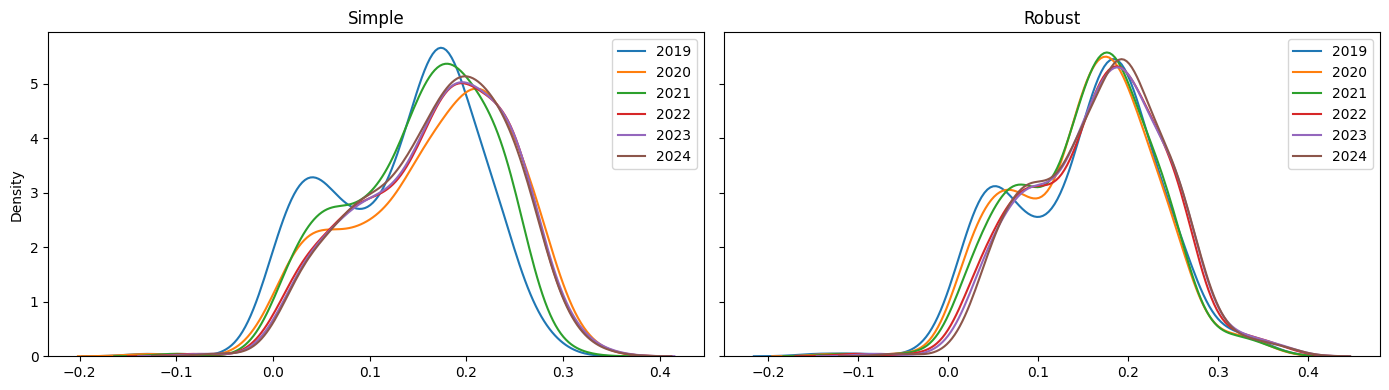

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Left column: Simple ---
for year in years:
    sns.kdeplot(
        corr[year].mean(),
        label=f"{year}",
        ax=axes[0]
    )

axes[0].set_title("Simple")
axes[0].legend()

    # --- Right column: Robust ---
for year in years:
    sns.kdeplot(
        robust_corr[year].mean(),
        label=f"{year}",
        ax=axes[1]
    )

axes[1].set_title("Robust")
axes[1].legend()

plt.tight_layout()
plt.show()

In [129]:
graph = {}

# Lista de todas as tarefas (ano, velocidade)
tasks = [year for year in years]

# Barra de progresso
for year in tqdm(tasks, desc="Construindo grafos"):
    # Recupera a matriz de correlação (DataFrame com nomes dos ativos)
    corr_matrix = robust_corr[year]

    # Constroi o grafo TMFG
    G = get_network_TMFG(corr_matrix)

    # Cria a pasta se não existir e salva
    base_path = f"../../data/04_graphs/{year}"
    os.makedirs(base_path, exist_ok=True)
    file_path = os.path.join(base_path, f"graph.gpickle")
    with open(file_path, "wb") as f:
        pickle.dump(G, f)

    # Armazena no dicionário
    graph[f"graph_{year}"] = G

Construindo grafos: 100%|██████████| 6/6 [01:10<00:00, 11.74s/it]


In [49]:
modes_list = ["fast", "medium", "slow"]
years = range(2019, 2025)
robust_corr = {}

for year in years:
    for mode in modes_list:
        temp = modes[f"{mode}_{year}"]

        window_days = 252
        years_back = 9
        tau = 250

        # Pick a single reference point - the last available date for this year
        t_idx = len(temp) - 1  # End of data
        t = temp.index[t_idx]
        
        corr_matrices_window = []

        # Loop over previous 9 years
        for k in range(years_back):
            window_end = t_idx - k * window_days
            window_start = window_end - window_days

            # Check if we have enough historical data
            if window_start >= 0:
                window = temp.iloc[window_start:window_end]

                if len(window) == window_days:
                    weights = exponential_weights(len(window), tau=tau)
                    weighted_corr = weighted_correlation(window, weights)
                    corr_matrices_window.append(weighted_corr)

        # Reverse to chronological order
        corr_matrices_window = corr_matrices_window[::-1]

        # Average + shrink - ONE matrix per mode-year
        robust_corr_matrix = shrinkage_correlation(corr_matrices_window)

        # Save
        robust_corr[f"corr_{mode}_{year}"] = robust_corr_matrix

        print(f"Mode: {mode} Year {year}: built {len(corr_matrices_window)} yearly matrices")

Mode: fast Year 2019: built 9 yearly matrices
Mode: medium Year 2019: built 9 yearly matrices
Mode: slow Year 2019: built 9 yearly matrices
Mode: fast Year 2020: built 9 yearly matrices
Mode: medium Year 2020: built 9 yearly matrices
Mode: slow Year 2020: built 9 yearly matrices
Mode: fast Year 2021: built 9 yearly matrices
Mode: medium Year 2021: built 9 yearly matrices
Mode: slow Year 2021: built 9 yearly matrices
Mode: fast Year 2022: built 9 yearly matrices
Mode: medium Year 2022: built 9 yearly matrices
Mode: slow Year 2022: built 9 yearly matrices
Mode: fast Year 2023: built 9 yearly matrices
Mode: medium Year 2023: built 9 yearly matrices
Mode: slow Year 2023: built 9 yearly matrices
Mode: fast Year 2024: built 9 yearly matrices
Mode: medium Year 2024: built 9 yearly matrices
Mode: slow Year 2024: built 9 yearly matrices


In [7]:
# modes_list = ["fast", "medium", "slow"]
# years = range(2019, 2025)
# robust_corr = {}

# for year in years:
#     for mode in modes_list:
#         temp = modes[f"{mode}_{year}"]

#         window_days = 252
#         years_back = 9
#         tau = 250

#         start_idx = window_days * years_back

#         for t_idx in range(start_idx, len(temp), window_days):

#             t = temp.index[t_idx]
#             corr_matrices_window = []

#             # Loop over previous 9 years
#             for k in range(years_back):
#                 window_end = t_idx - k * window_days
#                 window_start = window_end - window_days

#                 window = temp.iloc[window_start:window_end]

#                 if len(window) == window_days:
#                     weights = exponential_weights(len(window), tau=tau)
#                     weighted_corr = weighted_correlation(window, weights)
#                     corr_matrices_window.append(weighted_corr)

#             # Reverse to chronological order (optional)
#             corr_matrices_window = corr_matrices_window[::-1]

#             # Average + shrink
#             robust_corr_matrix = shrinkage_correlation(corr_matrices_window)

#             # Save
#             robust_corr[f"corr_{mode}_{year}"] = robust_corr_matrix

#             print(f"Mode: {mode} Year {t.year}: built {len(corr_matrices_window)} yearly matrices")

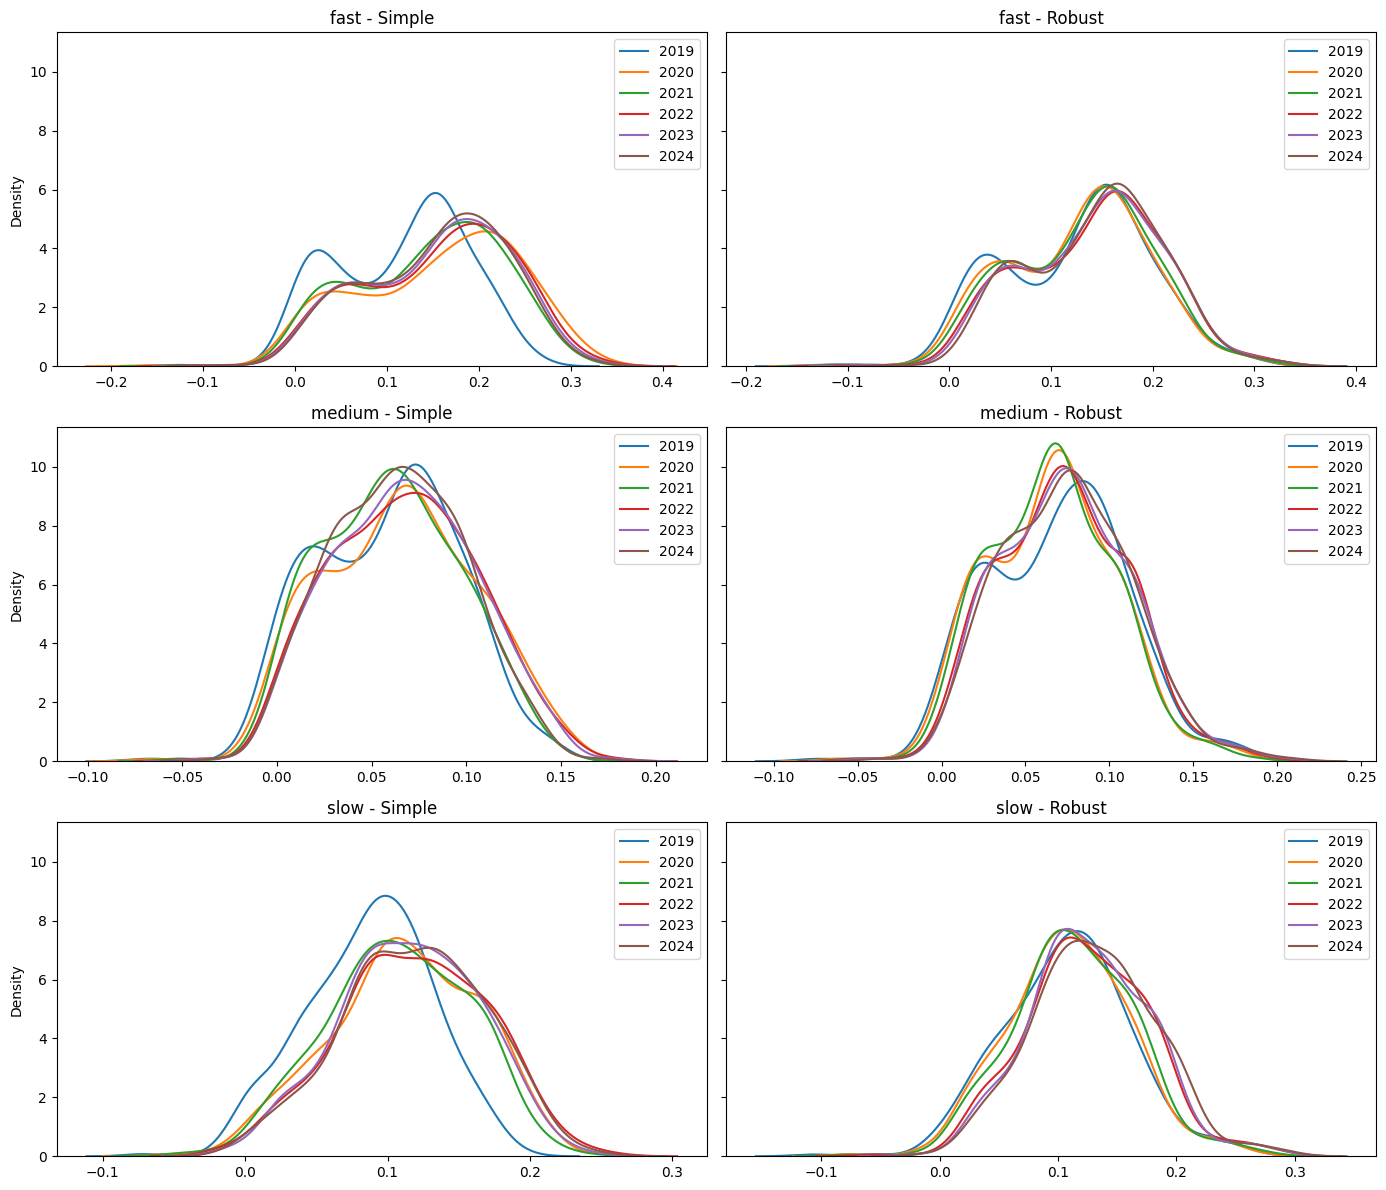

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

n_modes = len(modes_list)

fig, axes = plt.subplots(n_modes, 2, figsize=(14, 4 * n_modes), sharey=True)

# If only 1 mode, make axes 2D
if n_modes == 1:
    axes = axes.reshape(1, -1)

for i, mode in enumerate(modes_list):

    # --- Left column: Simple ---
    for year in years:
        sns.kdeplot(
            corr[f"corr_{mode}_{year}"].mean(),
            label=f"{year}",
            ax=axes[i, 0]
        )

    axes[i, 0].set_title(f"{mode} - Simple")
    axes[i, 0].legend()

    # --- Right column: Robust ---
    for year in years:
        sns.kdeplot(
            robust_corr[f"corr_{mode}_{year}"].mean(),
            label=f"{year}",
            ax=axes[i, 1]
        )

    axes[i, 1].set_title(f"{mode} - Robust")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

In [51]:
def align_corr_matrices(C0, C1):
    common = C0.columns.intersection(C1.columns)

    C0a = C0.loc[common, common]
    C1a = C1.loc[common, common]

    return C0a, C1a

def flatten_corr_matrix(C):
    """
    Extract upper-triangular elements (excluding diagonal)
    """
    iu = np.triu_indices_from(C, k=1)
    return C.values[iu]

def matrix_autocorr(C_t, C_t1, method="pearson"):
    v1 = flatten_corr_matrix(C_t)
    v2 = flatten_corr_matrix(C_t1)

    if method == "pearson":
        return np.corrcoef(v1, v2)[0, 1]
    elif method == "spearman":
        from scipy.stats import spearmanr
        return spearmanr(v1, v2).correlation
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

matrix_autocorr_results_simple = {"fast": {}, "medium": {}, "slow": {}}
matrix_autocorr_results_robust = {"fast": {}, "medium": {}, "slow": {}}

for mode in ["fast", "medium", "slow"]:
    for y0, y1 in zip(years[:-1], years[1:]):
        C0 = corr[f"corr_{mode}_{y0}"]
        C1 = corr[f"corr_{mode}_{y1}"]

        C2 = robust_corr[f"corr_{mode}_{y0}"]
        C3 = robust_corr[f"corr_{mode}_{y1}"]

        C0, C1 = align_corr_matrices(C0, C1)
        C2, C3 = align_corr_matrices(C2, C3)

        matrix_autocorr_results_simple[mode][f"{y0}-{y1}"] = matrix_autocorr(C0, C1)
        matrix_autocorr_results_robust[mode][f"{y0}-{y1}"] = matrix_autocorr(C2, C3)

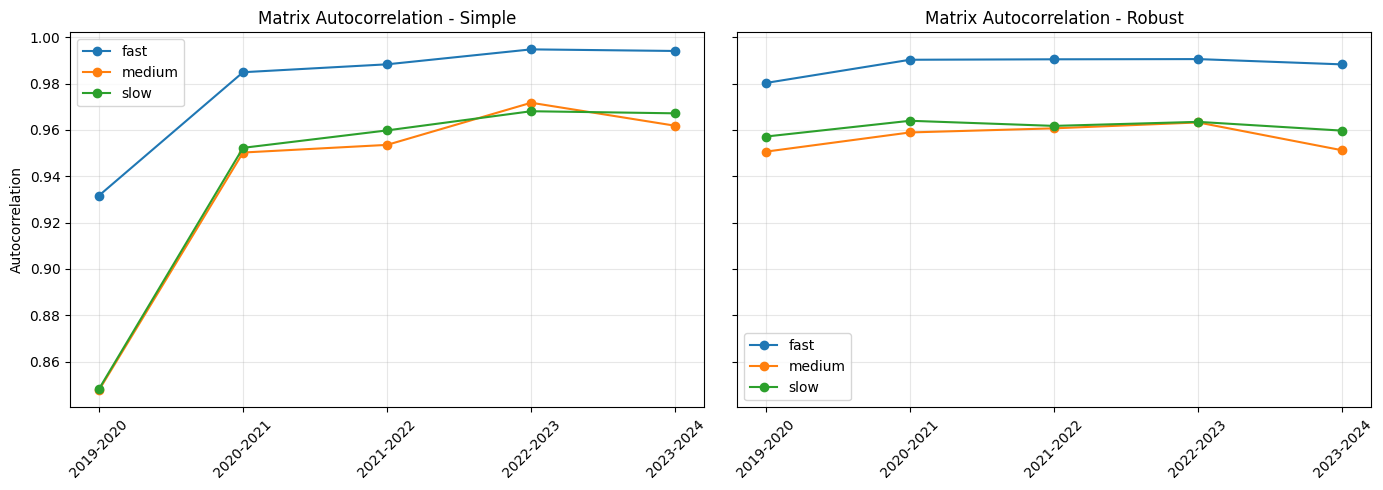

In [52]:
import matplotlib.pyplot as plt

year_pairs = [f"{y0}-{y1}" for y0, y1 in zip(years[:-1], years[1:])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---- LEFT: Simple ----
for mode in modes_list:
    values = [matrix_autocorr_results_simple[mode][yp] for yp in year_pairs]
    axes[0].plot(year_pairs, values, marker='o', label=mode)

axes[0].set_title("Matrix Autocorrelation - Simple")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_xticks(range(len(year_pairs)))
axes[0].set_xticklabels(year_pairs, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- RIGHT: Robust ----
for mode in modes_list:
    values = [matrix_autocorr_results_robust[mode][yp] for yp in year_pairs]
    axes[1].plot(year_pairs, values, marker='o', label=mode)

axes[1].set_title("Matrix Autocorrelation - Robust")
axes[1].set_xticks(range(len(year_pairs)))
axes[1].set_xticklabels(year_pairs, rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
graph = {}

# Lista de todas as tarefas (ano, velocidade)
tasks = [(year, speed) for year in years for speed in ["fast", "medium", "slow"]]

# Barra de progresso
for year, speed in tqdm(tasks, desc="Construindo grafos"):
    # Recupera a matriz de correlação (DataFrame com nomes dos ativos)
    corr_matrix = robust_corr[f"corr_{speed}_{year}"]

    # Constroi o grafo TMFG
    G = get_network_TMFG(corr_matrix)

    # Cria a pasta se não existir e salva
    base_path = f"../../data/04_graphs/{year}"
    os.makedirs(base_path, exist_ok=True)
    file_path = os.path.join(base_path, f"{speed}_graph.gpickle")
    with open(file_path, "wb") as f:
        pickle.dump(G, f)

    # Armazena no dicionário
    graph[f"graph_{speed}_{year}"] = G

Construindo grafos: 100%|██████████| 18/18 [03:57<00:00, 13.21s/it]
